# OSV Demo On Real F3 SEG-Y Data — 2.5D

This notebook does the following:
1. Loads the real SEG-Y seismic volume from `data/F3/1_Original_Seismics.sgy`.
2. Loads or computes the cached full-volume 3D FaultSeg prediction.
3. Checks the project for native 3D OSV support.
4. Uses a **2.5D fallback** when no runnable 3D SEG-Y pipeline exists: it processes every inline or every crossline with the existing 2D OSV runner and reassembles the outputs into a 3D cube.
5. Displays the resulting seismic, FaultSeg, and OSV outputs in an interactive 3-panel inline / crossline / timeslice viewer.

3D support status in this repo:
- The paper and source code support true 3D optimal surface voting conceptually.
- The repo contains `FaultOrientScanner3`, `OptimalSurfaceVoter`, and demo scripts such as `src/osv/demoF3d.py`.
- The repo does **not** contain a runnable `tools`-level 3D runner for SEG-Y volumes.
- This notebook therefore implements the requested whole-volume 2.5D workflow using the existing `tools/OSV2DRunner.java`.

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import segyio
import ipywidgets as widgets
from IPython.display import display

PROJECT_ROOT = Path('/home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV')
SGY_PATH = PROJECT_ROOT / 'data/F3/1_Original_Seismics.sgy'
WORK_DIR = PROJECT_ROOT / 'notebooks' / 'osv_runtime_2p5d'
WORK_DIR.mkdir(parents=True, exist_ok=True)

FAULTSEG_DIR = PROJECT_ROOT / 'faultSeg_2019_pyTorch'
TOOLS_DIR = PROJECT_ROOT / 'tools'
for path in (FAULTSEG_DIR, TOOLS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

INLINE_COLOR = 'magenta'
XLINE_COLOR = 'lime'
TIMESLICE_COLOR = 'cyan'

def normalize_for_display(section):
    section = np.nan_to_num(section.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    p1, p99 = np.percentile(section, [1, 99])
    section = np.clip(section, p1, p99)
    scale = np.max(np.abs(section)) + 1.0e-6
    return section / scale

print('Project root:', PROJECT_ROOT)
print('SEG-Y file:', SGY_PATH)
print('2.5D work dir:', WORK_DIR)

Project root: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV
SEG-Y file: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/data/F3/1_Original_Seismics.sgy
2.5D work dir: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime_2p5d


In [2]:
with segyio.open(str(SGY_PATH), mode='r', ignore_geometry=True) as f:
    f.mmap()
    il = np.asarray(f.attributes(segyio.TraceField.INLINE_3D)[:])
    xl = np.asarray(f.attributes(segyio.TraceField.CROSSLINE_3D)[:])
    samples = np.asarray(f.samples, dtype=np.float32)

    unique_il = np.unique(il).astype(int)
    unique_xl = np.unique(xl).astype(int)
    default_inline_index = len(unique_il) // 2
    default_xline_index = len(unique_xl) // 2
    default_sample_index = len(samples) // 2

    preview_inline_id = int(unique_il[default_inline_index])
    preview_indices = np.where(il == preview_inline_id)[0]
    preview_indices = preview_indices[np.argsort(xl[preview_indices])]
    preview_section = np.stack([np.asarray(f.trace[int(i)], dtype=np.float32) for i in preview_indices], axis=1)

preview_section = normalize_for_display(preview_section)

print(f'Samples: {len(samples)}')
print(f'Inline count: {len(unique_il)}  range: {unique_il[0]} - {unique_il[-1]}')
print(f'Crossline count: {len(unique_xl)}  range: {unique_xl[0]} - {unique_xl[-1]}')
print(f'Preview inline id: {preview_inline_id}')
print(f'Full volume shape will be [n1, n2, n3] = ({len(samples)}, {len(unique_il)}, {len(unique_xl)})')

Samples: 463
Inline count: 651  range: 100 - 750
Crossline count: 951  range: 300 - 1250
Preview inline id: 425
Full volume shape will be [n1, n2, n3] = (463, 651, 951)


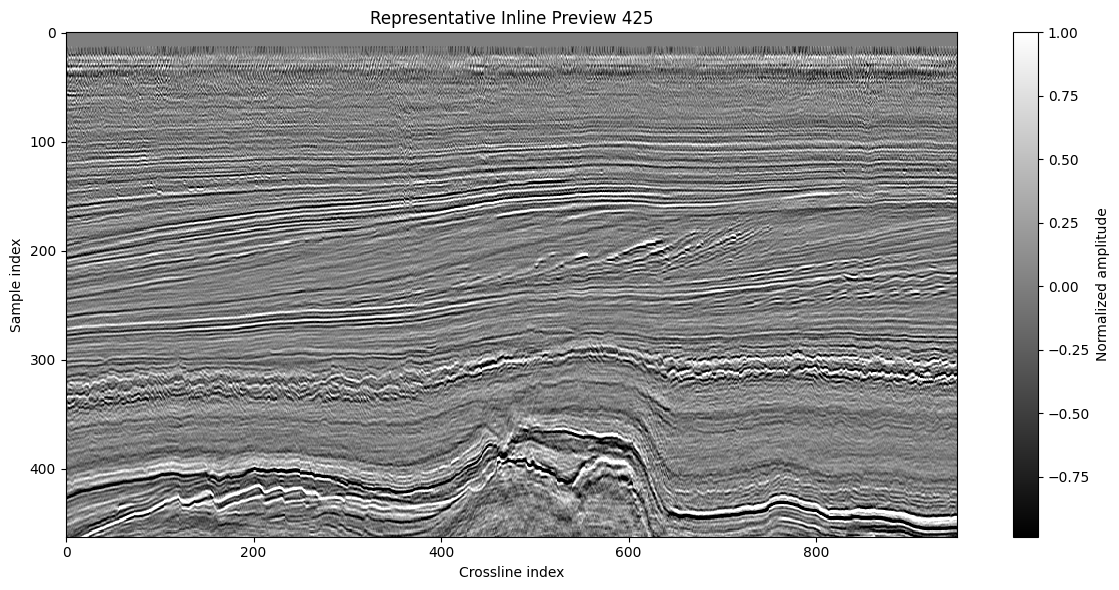

In [3]:
plt.figure(figsize=(12, 6))
plt.imshow(preview_section, cmap='gray', aspect='auto', interpolation='nearest')
plt.title(f'Representative Inline Preview {preview_inline_id}')
plt.xlabel('Crossline index')
plt.ylabel('Sample index')
plt.colorbar(label='Normalized amplitude')
plt.tight_layout()
plt.show()

In [4]:
FAULTSEG_OUTPUT_DIR = WORK_DIR / 'faultseg_outputs'
FAULTSEG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

faultseg_volume_path = FAULTSEG_OUTPUT_DIR / 'faultseg_volume.npy'
seismic_volume_path = FAULTSEG_OUTPUT_DIR / 'seismic_volume.npy'
faultseg_volume_meta_path = FAULTSEG_OUTPUT_DIR / 'faultseg_volume_meta.json'

print('FaultSeg output dir:', FAULTSEG_OUTPUT_DIR)
print('3D FaultSeg volume cache:', faultseg_volume_path)
print('3D support in repo:')
print('  - src/osv/FaultOrientScanner3.java: present')
print('  - src/osv/OptimalSurfaceVoter.java: present')
print('  - src/osv/demoF3d.py: present')
print('  - tools/OSV3D runner: not present')

FaultSeg output dir: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime_2p5d/faultseg_outputs
3D FaultSeg volume cache: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime_2p5d/faultseg_outputs/faultseg_volume.npy
3D support in repo:
  - src/osv/FaultOrientScanner3.java: present
  - src/osv/OptimalSurfaceVoter.java: present
  - src/osv/demoF3d.py: present
  - tools/OSV3D runner: not present


In [5]:
RUN_FULL_VOLUME_FAULTSEG = False

if faultseg_volume_meta_path.exists() and faultseg_volume_path.exists() and seismic_volume_path.exists():
    volume_meta = json.loads(faultseg_volume_meta_path.read_text(encoding='utf-8'))
    print('Using cached full 3D FaultSeg volume:')
    print(json.dumps({
        'n1': volume_meta['n1'],
        'n2': volume_meta['n2'],
        'n3': volume_meta['n3'],
        'device': volume_meta['device'],
        'fault_volume_npy': volume_meta['fault_volume_npy'],
    }, indent=2))
elif RUN_FULL_VOLUME_FAULTSEG:
    from predict_sgy_inline import run_full_volume_prediction

    volume_meta = run_full_volume_prediction(
        sgy_path=SGY_PATH,
        output_dir=FAULTSEG_OUTPUT_DIR,
        chunk_inlines=128,
        chunk_overlap=32,
    )
    print('Computed full 3D FaultSeg volume:')
    print(json.dumps({
        'n1': volume_meta['n1'],
        'n2': volume_meta['n2'],
        'n3': volume_meta['n3'],
        'device': volume_meta['device'],
        'fault_volume_npy': volume_meta['fault_volume_npy'],
    }, indent=2))
else:
    volume_meta = None
    print(
        'Full 3D FaultSeg volume not computed yet. '
        'Set RUN_FULL_VOLUME_FAULTSEG=True in this cell to generate it '
        '(cached to faultseg_outputs/faultseg_volume.npy).'
)

Full 3D FaultSeg volume not computed yet. Set RUN_FULL_VOLUME_FAULTSEG=True in this cell to generate it (cached to faultseg_outputs/faultseg_volume.npy).


In [6]:
from osv_2p5d_volume import run_volume_osv_2p5d, run_volume_osv_2p5d_from_sgy

OSV_2P5D_AXIS = 'inline'
RUN_OSV_2P5D = False
MAX_2P5D_SECTIONS = None  # set an integer for quick tests; None runs the full axis
SHARPEN_POWER = 2.0
OSV_EXTRACT_THRESHOLD = 0.20

osv_2p5d_root = WORK_DIR / 'osv_2p5d_outputs'
osv_2p5d_output_dir = osv_2p5d_root / OSV_2P5D_AXIS
osv_2p5d_output_dir.mkdir(parents=True, exist_ok=True)
osv_2p5d_meta_path = osv_2p5d_output_dir / 'osv_2p5d_meta.json'

# Important: RUN_OSV_2P5D=True should resume/compute, even if a cache exists.
if RUN_OSV_2P5D:
    if volume_meta is not None:
        # Fast path: 3D FaultSeg cache already exists — use pre-built volumes
        osv_2p5d_meta = run_volume_osv_2p5d(
            project_root=PROJECT_ROOT,
            seismic_volume_path=seismic_volume_path,
            faultseg_volume_path=faultseg_volume_path,
            output_dir=osv_2p5d_output_dir,
            axis=OSV_2P5D_AXIS,
            sharpen_power=SHARPEN_POWER,
            extract_threshold=OSV_EXTRACT_THRESHOLD,
            max_sections=MAX_2P5D_SECTIONS,
        )
    else:
        # Standard 2.5D path: FaultSeg + OSV computed per-section from SEG-Y
        # Supports checkpoint/resume when output files already exist.
        osv_2p5d_meta = run_volume_osv_2p5d_from_sgy(
            project_root=PROJECT_ROOT,
            sgy_path=SGY_PATH,
            faultseg_dir=FAULTSEG_DIR,
            output_dir=osv_2p5d_output_dir,
            axis=OSV_2P5D_AXIS,
            sharpen_power=SHARPEN_POWER,
            extract_threshold=OSV_EXTRACT_THRESHOLD,
            max_sections=MAX_2P5D_SECTIONS,
        )
    print('Computed or resumed 2.5D OSV volume:')
    print(json.dumps({
        'axis': osv_2p5d_meta['axis'],
        'shape': osv_2p5d_meta['shape'],
        'sections_processed': osv_2p5d_meta['sections_processed'],
        'extract_threshold': osv_2p5d_meta['extract_threshold'],
    }, indent=2))
elif osv_2p5d_meta_path.exists():
    osv_2p5d_meta = json.loads(osv_2p5d_meta_path.read_text(encoding='utf-8'))
    print('Using cached 2.5D OSV volume:')
    print(json.dumps({
        'axis': osv_2p5d_meta['axis'],
        'shape': osv_2p5d_meta['shape'],
        'sections_processed': osv_2p5d_meta['sections_processed'],
        'extract_threshold': osv_2p5d_meta['extract_threshold'],
    }, indent=2))
else:
    osv_2p5d_meta = None
    print(
        '2.5D OSV volume not computed yet. '
        'Choose OSV_2P5D_AXIS (inline or crossline), optionally set MAX_2P5D_SECTIONS for a quick test, '
        'then set RUN_OSV_2P5D=True in this cell.'
    )

Using cached 2.5D OSV volume:
{
  "axis": "inline",
  "shape": [
    463,
    651,
    951
  ],
  "sections_processed": 120,
  "extract_threshold": 0.2
}


In [ ]:
import time
import threading
import ipywidgets as widgets
from IPython.display import display

_sections_dir = osv_2p5d_output_dir / 'sections'
_total = len(unique_il) if OSV_2P5D_AXIS == 'inline' else len(unique_xl)
_rate_approx = 12  # sections per minute (observed)

def _count_done():
    if not _sections_dir.exists():
        return 0
    return len(list(_sections_dir.glob(f'{OSV_2P5D_AXIS}_*_fvtg_binary.npy')))

_done_now = _count_done()

bar = widgets.IntProgress(
    value=_done_now, min=0, max=_total,
    description='OSV:',
    bar_style='info',
    style={'bar_color': '#ff6600', 'description_width': '40px'},
    layout=widgets.Layout(width='70%'),
)
pct_label  = widgets.Label(value=f'{_done_now}/{_total}  ({_done_now/_total*100:.1f}%)')
eta_label  = widgets.Label(value='')
status_box = widgets.VBox([
    widgets.HBox([bar, pct_label]),
    eta_label,
])
display(status_box)

_stop_flag = threading.Event()

def _update_loop():
    while not _stop_flag.is_set():
        done = _count_done()
        bar.value = done
        pct = done / _total * 100
        pct_label.value = f'{done}/{_total}  ({pct:.1f}%)'
        if done >= _total:
            bar.bar_style = 'success'
            eta_label.value = 'COMPLETE — re-run Cell 9 (loader) then Cell 10 (viewer) to see full OSV coverage.'
            break
        remaining = _total - done
        eta_min = remaining / _rate_approx
        eta_label.value = f'~{eta_min:.0f} min remaining at ~{_rate_approx} sections/min   (last checked: {time.strftime("%H:%M:%S")})'
        _stop_flag.wait(timeout=10)

_t = threading.Thread(target=_update_loop, daemon=True)
_t.start()

In [ ]:
# ── Assemble intermediate volumes from checkpoints ──────────────────────────
# Run this cell at any time while the background process is running to reload
# the viewer with whatever sections have been completed so far.
# It reads each per-section checkpoint and assembles fresh .npy volumes + meta.

_sections_dir = osv_2p5d_output_dir / 'sections'
_axis = OSV_2P5D_AXIS

if not _sections_dir.exists():
    print('No sections directory found. Run Cell 7 first.')
else:
    _checkpoint_files = sorted(_sections_dir.glob(f'{_axis}_*_fvtg_binary.npy'))
    _n_done = len(_checkpoint_files)
    _total = len(unique_il) if _axis == 'inline' else len(unique_xl)

    if _n_done == 0:
        print('No checkpoints found yet.')
    else:
        print(f'Assembling {_n_done}/{_total} {_axis} sections from checkpoints…')

        # Load seismic dims from SEG-Y headers (fast, no data load)
        with segyio.open(str(SGY_PATH), mode='r', ignore_geometry=True) as _f:
            _il_all = np.unique(np.asarray(_f.attributes(segyio.TraceField.INLINE_3D)[:])).astype(int)
            _xl_all = np.unique(np.asarray(_f.attributes(segyio.TraceField.CROSSLINE_3D)[:])).astype(int)
            _n1     = len(np.asarray(_f.samples))
        _n2, _n3 = len(_il_all), len(_xl_all)

        _fvtg_v   = np.zeros((_n1, _n2, _n3), dtype=np.float32)
        _fvtg_b_v = np.zeros((_n1, _n2, _n3), dtype=np.float32)
        _fvg_v    = np.zeros((_n1, _n2, _n3), dtype=np.float32)
        _fault_v  = np.zeros((_n1, _n2, _n3), dtype=np.float32)

        for _cf in _checkpoint_files:
            _idx = int(_cf.stem.split('_')[1])
            _fvtg_v[:,   _idx, :] = np.load(_cf.parent / f'{_axis}_{_idx:04d}_fvtg.npy')
            _fvtg_b_v[:, _idx, :] = np.load(_cf)
            _fvg_v[:,    _idx, :] = np.load(_cf.parent / f'{_axis}_{_idx:04d}_fvg.npy')
            _fa_path = _cf.parent / f'{_axis}_{_idx:04d}_faultseg.npy'
            if _fa_path.exists():
                _fault_v[:, _idx, :] = np.load(_fa_path)

        print('  Saving assembled volumes…', end=' ', flush=True)
        np.save(osv_2p5d_output_dir / 'fvtg_volume.npy',        _fvtg_v)
        np.save(osv_2p5d_output_dir / 'fvtg_binary_volume.npy', _fvtg_b_v)
        np.save(osv_2p5d_output_dir / 'fvg_volume.npy',         _fvg_v)
        np.save(osv_2p5d_output_dir / 'faultseg_volume.npy',    _fault_v)
        # seismic_volume.npy is written once by the run and never changes — skip re-save

        _meta = {
            'axis':                   _axis,
            'shape':                  [int(_n1), int(_n2), int(_n3)],
            'inline_ids':             _il_all.tolist(),
            'xline_ids':              _xl_all.tolist(),
            'sharpen_power':          float(SHARPEN_POWER),
            'extract_threshold':      float(OSV_EXTRACT_THRESHOLD),
            'sections_processed':     int(_n_done),
            'total_sections':         int(_total),
            'fvtg_volume_npy':        str(osv_2p5d_output_dir / 'fvtg_volume.npy'),
            'fvtg_binary_volume_npy': str(osv_2p5d_output_dir / 'fvtg_binary_volume.npy'),
            'fvg_volume_npy':         str(osv_2p5d_output_dir / 'fvg_volume.npy'),
            'seismic_volume_npy':     str(osv_2p5d_output_dir / 'seismic_volume.npy'),
            'faultseg_volume_npy':    str(osv_2p5d_output_dir / 'faultseg_volume.npy'),
        }
        (osv_2p5d_output_dir / 'osv_2p5d_meta.json').write_text(
            json.dumps(_meta, indent=2), encoding='utf-8')

        print('done.')
        print(f'  {_n_done}/{_total} sections assembled ({_n_done/_total*100:.1f}% coverage).')
        print('  Re-run Cell 9 (loader) then Cell 10 (viewer) to refresh.')


Assembling 278/651 inline sections from checkpoints…
  Saving assembled volumes… done.
  278/651 sections assembled (42.7% coverage).
  Re-run Cell 9 (loader) then Cell 10 (viewer) to refresh.


In [ ]:
# Load seismic and FaultSeg cubes — check OSV output dir first (when from-sgy run),
# then fall back to the full 3D FaultSeg cache, then load from SEG-Y if needed.
# Also reload the meta.json from disk to pick up any updates from the assemble cell.
if osv_2p5d_meta_path.exists():
    osv_2p5d_meta = json.loads(osv_2p5d_meta_path.read_text(encoding='utf-8'))

seismic_cube = None
faultseg_cube = None
inline_ids = unique_il
xline_ids = unique_xl

if osv_2p5d_meta is not None and osv_2p5d_meta.get('seismic_volume_npy'):
    _seis_path = Path(osv_2p5d_meta['seismic_volume_npy'])
    _fault_path = Path(osv_2p5d_meta['faultseg_volume_npy'])
    if _seis_path.exists() and _fault_path.exists():
        try:
            seismic_cube = np.load(_seis_path, mmap_mode='r')
            faultseg_cube = np.load(_fault_path, mmap_mode='r')
            inline_ids = np.asarray(osv_2p5d_meta.get('inline_ids', unique_il), dtype=int)
            xline_ids = np.asarray(osv_2p5d_meta.get('xline_ids', unique_xl), dtype=int)
        except (ValueError, OSError, RuntimeError) as e:
            print(f'  Warning: failed to mmap {_seis_path.name}: {e.__class__.__name__}. Deleting corrupted file.')
            _seis_path.unlink(missing_ok=True)
            seismic_cube = None
            faultseg_cube = None

if seismic_cube is None and volume_meta is not None and faultseg_volume_path.exists() and seismic_volume_path.exists():
    try:
        seismic_cube = np.load(seismic_volume_path, mmap_mode='r')
        faultseg_cube = np.load(faultseg_volume_path, mmap_mode='r')
        inline_ids = np.asarray(volume_meta.get('inline_ids', unique_il), dtype=int)
        xline_ids = np.asarray(volume_meta.get('xline_ids', unique_xl), dtype=int)
    except (ValueError, OSError, RuntimeError):
        seismic_cube = None
        faultseg_cube = None

# If seismic cube still not loaded, load it directly from SEG-Y
if seismic_cube is None and SGY_PATH.exists():
    print('Loading seismic cube from SEG-Y…', end=' ', flush=True)
    with segyio.open(str(SGY_PATH), mode='r', ignore_geometry=True) as _f:
        _il = np.asarray(_f.attributes(segyio.TraceField.INLINE_3D)[:])
        _xl = np.asarray(_f.attributes(segyio.TraceField.CROSSLINE_3D)[:])
        _samples = np.asarray(_f.samples, dtype=np.float32)
        _il_idx = {v: i for i, v in enumerate(np.unique(_il.astype(int)))}
        _xl_idx = {v: i for i, v in enumerate(np.unique(_xl.astype(int)))}
        _cube = np.zeros((len(_samples), len(_il_idx), len(_xl_idx)), dtype=np.float32)
        for _trace_idx in range(_f.tracecount):
            _i = _il_idx[int(_il[_trace_idx])]
            _j = _xl_idx[int(_xl[_trace_idx])]
            _cube[:, _i, _j] = np.asarray(_f.trace[_trace_idx], dtype=np.float32)
        seismic_cube = _cube
        inline_ids = np.asarray(sorted(_il_idx.keys()), dtype=int)
        xline_ids = np.asarray(sorted(_xl_idx.keys()), dtype=int)
    print('done.')

osv_continuous_cube = None
osv_binary_cube = None
if osv_2p5d_meta is not None:
    try:
        osv_continuous_cube = np.load(Path(osv_2p5d_meta['fvtg_volume_npy']), mmap_mode='r')
        osv_binary_cube = np.load(Path(osv_2p5d_meta['fvtg_binary_volume_npy']), mmap_mode='r')
    except (ValueError, OSError, RuntimeError) as e:
        print(f'  Warning: failed to load OSV volumes: {e.__class__.__name__}')

coverage_axis = None
coverage_sections = 0
coverage_fraction = 0.0
if osv_2p5d_meta is not None:
    coverage_axis = str(osv_2p5d_meta.get('axis', 'inline'))
    coverage_sections = int(osv_2p5d_meta.get('sections_processed', 0))
    fallback_total = len(unique_il) if coverage_axis == 'inline' else len(unique_xl)
    total_sections = int(osv_2p5d_meta.get('total_sections', fallback_total))
    coverage_fraction = coverage_sections / total_sections if total_sections > 0 else 0.0

print('Volume availability:')
print('  seismic cube   :', None if seismic_cube is None else seismic_cube.shape)
print('  faultseg cube  :', None if faultseg_cube is None else faultseg_cube.shape)
print('  osv continuous :', None if osv_continuous_cube is None else osv_continuous_cube.shape)
print('  osv binary     :', None if osv_binary_cube is None else osv_binary_cube.shape)
if osv_2p5d_meta is not None:
    print('2.5D mode axis  :', osv_2p5d_meta['axis'])
    print('Sections processed:', osv_2p5d_meta['sections_processed'], '/', osv_2p5d_meta['total_sections'])
    if coverage_fraction < 0.999:
        print(
            'Partial coverage warning: FaultSeg and OSV cubes loaded from the 2.5D run are only populated '
            f'for the first {coverage_sections} {coverage_axis} sections '
            f'({coverage_fraction:.1%} of the volume). Crossline and timeslice views will therefore look partial.'
        )


Loading seismic cube from SEG-Y… 

done.
Volume availability:
  seismic cube   : (463, 651, 951)
  faultseg cube  : None
  osv continuous : (463, 651, 951)
  osv binary     : (463, 651, 951)
2.5D mode axis  : inline
Sections processed: 278 / 651
Partial coverage warning: FaultSeg and OSV cubes loaded from the 2.5D run are only populated for the first 278 inline sections (42.7% of the volume). Crossline and timeslice views will therefore look partial.


In [16]:
import ipywidgets as widgets
from IPython.display import display

if seismic_cube is None:
    print('Viewer unavailable until volumes are loaded. Run Cells 7-8 first.')
else:
    n_samples, n_inlines, n_xlines = seismic_cube.shape

    processed_sections = None
    processed_axis = None
    if osv_2p5d_meta is not None:
        processed_sections = int(osv_2p5d_meta.get('sections_processed', 0))
        processed_axis = str(osv_2p5d_meta.get('axis', 'inline'))

    def _robust_limits(x, lo=0.02, hi=0.98):
        finite = np.asarray(x)[np.isfinite(x)]
        if finite.size == 0:
            return 0.0, 1.0
        vmin, vmax = np.quantile(finite, [lo, hi])
        if vmax <= vmin:
            vmax = vmin + 1.0e-6
        return float(vmin), float(vmax)

    def _nonzero_limits(x, lo_pct=2, hi_pct=99):
        nz = np.asarray(x)[np.asarray(x) > 0]
        if nz.size == 0:
            return 0.0, 1.0
        vmin = float(np.percentile(nz, lo_pct))
        vmax = float(np.percentile(nz, hi_pct))
        if vmax <= vmin:
            vmax = vmin + 1.0e-6
        return vmin, vmax

    def _rgba_overlay(mask2d, rgb, alpha):
        arr = np.asarray(mask2d, dtype=bool)
        overlay = np.zeros(arr.shape + (4,), dtype=float)
        overlay[..., 0] = rgb[0]
        overlay[..., 1] = rgb[1]
        overlay[..., 2] = rgb[2]
        overlay[..., 3] = arr.astype(float) * alpha
        return overlay

    def _fault_rgba_overlay(fault2d, alpha, threshold=0.20):
        fault_mask = np.asarray(fault2d) > threshold
        return _rgba_overlay(fault_mask, rgb=(0.0, 1.0, 0.25), alpha=min(0.5, alpha))

    def _osv_binary_rgba_overlay(osv2d, alpha):
        osv_mask = np.asarray(osv2d) > 0.0
        return _rgba_overlay(osv_mask, rgb=(1.0, 0.35, 0.0), alpha=alpha)

    def _partial_coverage_overlay(shape, view_name, inline_idx, crossline_idx, alpha=0.35):
        if processed_sections is None or processed_sections <= 0:
            return None
        if processed_axis == 'inline':
            if view_name == 'crossline':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[:, processed_sections:] = True
            elif view_name == 'timeslice':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[processed_sections:, :] = True
            else:
                return None if inline_idx < processed_sections else _rgba_overlay(np.ones(shape, dtype=bool), rgb=(0.7, 0.7, 0.7), alpha=alpha)
        elif processed_axis == 'crossline':
            if view_name == 'inline':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[:, processed_sections:] = True
            elif view_name == 'timeslice':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[:, processed_sections:] = True
            else:
                return None if crossline_idx < processed_sections else _rgba_overlay(np.ones(shape, dtype=bool), rgb=(0.7, 0.7, 0.7), alpha=alpha)
        else:
            return None
        return _rgba_overlay(invalid_mask, rgb=(0.7, 0.7, 0.7), alpha=alpha)

    def _mask(x, threshold):
        arr = np.asarray(x, dtype=np.float32)
        return np.ma.masked_where(arr <= threshold, arr)

    def _add_reference_lines(ax, view_name, inline_idx, crossline_idx, timeslice_idx):
        if view_name == 'inline':
            ax.axvline(crossline_idx, color=XLINE_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)
            ax.axhline(timeslice_idx, color=TIMESLICE_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)
        elif view_name == 'crossline':
            ax.axvline(inline_idx, color=INLINE_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)
            ax.axhline(timeslice_idx, color=TIMESLICE_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)
        elif view_name == 'timeslice':
            ax.axvline(crossline_idx, color=XLINE_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)
            ax.axhline(inline_idx, color=INLINE_COLOR, linestyle='--', linewidth=1.5, alpha=0.9)

    def _plot_view(
        ax,
        base2d,
        fault2d,
        osv2d,
        title,
        view_name,
        inline_idx,
        crossline_idx,
        timeslice_idx,
        show_fault,
        show_osv,
        osv_view,
        fault_thr,
        fault_alpha,
        osv_alpha,
        seis_vmin,
        seis_vmax,
    ):
        ax.imshow(base2d, cmap='gray', aspect='auto', interpolation='nearest', vmin=seis_vmin, vmax=seis_vmax)

        if show_fault and fault2d is not None:
            ax.imshow(_fault_rgba_overlay(fault2d, fault_alpha, threshold=fault_thr), aspect='auto')

        if show_osv and osv2d is not None:
            if osv_view == 'binary':
                ax.imshow(_osv_binary_rgba_overlay(osv2d, osv_alpha), aspect='auto')
            else:
                osv_vmin, osv_vmax = _nonzero_limits(osv2d)
                osv_overlay = _mask(osv2d, max(osv_vmin * 0.5, 1.0e-8))
                osv_cmap = plt.cm.hot.copy()
                osv_cmap.set_bad(alpha=0.0)
                ax.imshow(
                    osv_overlay,
                    cmap=osv_cmap,
                    aspect='auto',
                    interpolation='nearest',
                    alpha=osv_alpha,
                    vmin=osv_vmin,
                    vmax=osv_vmax,
                )

        partial_overlay = _partial_coverage_overlay(base2d.shape, view_name, inline_idx, crossline_idx, alpha=0.32)
        if partial_overlay is not None:
            ax.imshow(partial_overlay, aspect='auto')

        _add_reference_lines(ax, view_name, inline_idx, crossline_idx, timeslice_idx)
        ax.set_title(title)

    def _osv_selection_warning(inline_idx, crossline_idx):
        if processed_sections is None or processed_sections <= 0:
            return None
        if processed_axis == 'inline' and inline_idx >= processed_sections:
            return (
                f'Only the first {processed_sections} inline sections are currently populated. '
                f'Crossline and timeslice views are partial until more inline sections are processed.'
            )
        if processed_axis == 'crossline' and crossline_idx >= processed_sections:
            return (
                f'Only the first {processed_sections} crossline sections are currently populated. '
                f'Inline and timeslice views are partial until more crossline sections are processed.'
            )
        return (
            f'Partial 2.5D coverage: only the first {processed_sections} {processed_axis} sections are populated. '
            'Gray regions indicate unprocessed areas.'
        ) if processed_sections is not None and ((processed_axis == 'inline' and processed_sections < n_inlines) or (processed_axis == 'crossline' and processed_sections < n_xlines)) else None

    def render_sections(inline_idx, crossline_idx, timeslice_idx, show_fault, show_osv, osv_view, fault_thr, fault_alpha, osv_alpha):
        inline_id = int(inline_ids[inline_idx])
        xline_id = int(xline_ids[crossline_idx])

        inline_img = np.asarray(seismic_cube[:, inline_idx, :], dtype=np.float32)
        xline_img = np.asarray(seismic_cube[:, :, crossline_idx], dtype=np.float32)
        ts_img = np.asarray(seismic_cube[timeslice_idx, :, :], dtype=np.float32)

        inline_fault = np.asarray(faultseg_cube[:, inline_idx, :], dtype=np.float32) if faultseg_cube is not None else None
        xline_fault = np.asarray(faultseg_cube[:, :, crossline_idx], dtype=np.float32) if faultseg_cube is not None else None
        ts_fault = np.asarray(faultseg_cube[timeslice_idx, :, :], dtype=np.float32) if faultseg_cube is not None else None

        osv_cube = None
        if show_osv:
            osv_cube = osv_binary_cube if osv_view == 'binary' else osv_continuous_cube

        inline_osv = np.asarray(osv_cube[:, inline_idx, :], dtype=np.float32) if osv_cube is not None else None
        xline_osv = np.asarray(osv_cube[:, :, crossline_idx], dtype=np.float32) if osv_cube is not None else None
        ts_osv = np.asarray(osv_cube[timeslice_idx, :, :], dtype=np.float32) if osv_cube is not None else None

        seis_vmin, seis_vmax = _robust_limits(inline_img)

        fig, axs = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

        _plot_view(
            axs[0], inline_img, inline_fault, inline_osv,
            f'Inline {inline_id}', 'inline',
            inline_idx, crossline_idx, timeslice_idx,
            show_fault, show_osv, osv_view, fault_thr, fault_alpha, osv_alpha,
            seis_vmin, seis_vmax,
        )
        axs[0].set_xlabel('Crossline index')
        axs[0].set_ylabel('Sample index')

        _plot_view(
            axs[1], xline_img, xline_fault, xline_osv,
            f'Crossline {xline_id}', 'crossline',
            inline_idx, crossline_idx, timeslice_idx,
            show_fault, show_osv, osv_view, fault_thr, fault_alpha, osv_alpha,
            seis_vmin, seis_vmax,
        )
        axs[1].set_xlabel('Inline index')
        axs[1].set_ylabel('Sample index')

        _plot_view(
            axs[2], ts_img, ts_fault, ts_osv,
            f'Timeslice {timeslice_idx}', 'timeslice',
            inline_idx, crossline_idx, timeslice_idx,
            show_fault, show_osv, osv_view, fault_thr, fault_alpha, osv_alpha,
            seis_vmin, seis_vmax,
        )
        axs[2].set_xlabel('Crossline index')
        axs[2].set_ylabel('Inline index')

        mode_label = 'no OSV volume loaded' if osv_2p5d_meta is None else f"2.5D axis={osv_2p5d_meta['axis']}"
        fig.suptitle(
            f'Interactive Section Viewer | inline={inline_id} ({INLINE_COLOR}), '
            f'crossline={xline_id} ({XLINE_COLOR}), timeslice={timeslice_idx} ({TIMESLICE_COLOR}) | {mode_label}',
            fontsize=13,
        )

        warn_msg = _osv_selection_warning(inline_idx, crossline_idx)
        if warn_msg:
            fig.text(0.01, 0.01, warn_msg, color='yellow', fontsize=10)

        plt.show()
        plt.close(fig)

    if processed_axis == 'inline' and processed_sections and processed_sections > 0:
        default_inline_slider = min(default_inline_index, processed_sections - 1)
    else:
        default_inline_slider = min(default_inline_index, n_inlines - 1)

    if processed_axis == 'crossline' and processed_sections and processed_sections > 0:
        default_crossline_slider = min(default_xline_index, processed_sections - 1)
    else:
        default_crossline_slider = min(default_xline_index, n_xlines - 1)

    inline_slider = widgets.IntSlider(value=default_inline_slider, min=0, max=n_inlines - 1, step=1, description='Inline')
    crossline_slider = widgets.IntSlider(value=default_crossline_slider, min=0, max=n_xlines - 1, step=1, description='Crossline')
    timeslice_slider = widgets.IntSlider(value=min(default_sample_index, n_samples - 1), min=0, max=n_samples - 1, step=1, description='Timeslice')

    show_fault_cb = widgets.Checkbox(value=False, description='Overlay FaultSeg')
    show_osv_cb = widgets.Checkbox(value=osv_binary_cube is not None, description='Overlay OSV')
    osv_view_dd = widgets.Dropdown(
        options=[('Binary extraction', 'binary'), ('Continuous fvtg', 'continuous')],
        value='continuous',
        description='OSV view'
    )

    fault_thr_slider = widgets.FloatSlider(value=0.20, min=0.0, max=1.0, step=0.05, description='Fault thr')
    fault_alpha_slider = widgets.FloatSlider(value=0.18, min=0.05, max=0.6, step=0.05, description='Fault alpha')
    osv_alpha_slider = widgets.FloatSlider(value=0.85, min=0.05, max=1.0, step=0.05, description='OSV alpha')

    ui = widgets.VBox([
        widgets.HBox([inline_slider, crossline_slider, timeslice_slider]),
        widgets.HBox([show_fault_cb, show_osv_cb, osv_view_dd]),
        widgets.HBox([fault_thr_slider, fault_alpha_slider, osv_alpha_slider]),
    ])

    out = widgets.interactive_output(
        render_sections,
        {
            'inline_idx': inline_slider,
            'crossline_idx': crossline_slider,
            'timeslice_idx': timeslice_slider,
            'show_fault': show_fault_cb,
            'show_osv': show_osv_cb,
            'osv_view': osv_view_dd,
            'fault_thr': fault_thr_slider,
            'fault_alpha': fault_alpha_slider,
            'osv_alpha': osv_alpha_slider,
        },
    )

    display(ui, out)

Output()

In [ ]:
snapshot_path = WORK_DIR / 'osv_2p5d_three_panel_snapshot.png'

if seismic_cube is None:
    print('Snapshot unavailable until volumes are loaded.')
else:
    inline_idx = min(default_inline_index, len(inline_ids) - 1)
    xline_idx = min(default_xline_index, len(xline_ids) - 1)
    sample_idx = default_sample_index

    if 'coverage_axis' not in globals():
        coverage_axis = str(osv_2p5d_meta.get('axis', 'inline')) if osv_2p5d_meta is not None else None
        coverage_sections = int(osv_2p5d_meta.get('sections_processed', 0)) if osv_2p5d_meta is not None else 0

    def _rgba_overlay_snap(mask2d, rgb, alpha):
        arr = np.asarray(mask2d, dtype=bool)
        overlay = np.zeros(arr.shape + (4,), dtype=float)
        overlay[..., 0] = rgb[0]
        overlay[..., 1] = rgb[1]
        overlay[..., 2] = rgb[2]
        overlay[..., 3] = arr.astype(float) * alpha
        return overlay

    def _snap_coverage_overlay(shape, view_name):
        if osv_2p5d_meta is None or coverage_sections <= 0:
            return None
        if coverage_axis == 'inline':
            if view_name == 'crossline':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[:, coverage_sections:] = True
            elif view_name == 'timeslice':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[coverage_sections:, :] = True
            else:
                return None
        elif coverage_axis == 'crossline':
            if view_name == 'inline':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[:, coverage_sections:] = True
            elif view_name == 'timeslice':
                invalid_mask = np.zeros(shape, dtype=bool)
                invalid_mask[:, coverage_sections:] = True
            else:
                return None
        else:
            return None
        return _rgba_overlay_snap(invalid_mask, rgb=(0.7, 0.7, 0.7), alpha=0.32)

    inline_section = np.asarray(seismic_cube[:, inline_idx, :], dtype=np.float32)
    crossline_section = np.asarray(seismic_cube[:, :, xline_idx], dtype=np.float32)
    timeslice_section = np.asarray(seismic_cube[sample_idx, :, :], dtype=np.float32)

    seis_vmin, seis_vmax = np.quantile(inline_section[np.isfinite(inline_section)], [0.02, 0.98])

    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    axes[0].imshow(inline_section, cmap='gray', aspect='auto', interpolation='nearest', vmin=seis_vmin, vmax=seis_vmax)
    axes[1].imshow(crossline_section, cmap='gray', aspect='auto', interpolation='nearest', vmin=seis_vmin, vmax=seis_vmax)
    axes[2].imshow(timeslice_section, cmap='gray', aspect='auto', interpolation='nearest', vmin=seis_vmin, vmax=seis_vmax)

    if faultseg_cube is not None:
        fault_inline = np.ma.masked_where(faultseg_cube[:, inline_idx, :] <= 0.20, faultseg_cube[:, inline_idx, :])
        fault_crossline = np.ma.masked_where(faultseg_cube[:, :, xline_idx] <= 0.20, faultseg_cube[:, :, xline_idx])
        fault_timeslice = np.ma.masked_where(faultseg_cube[sample_idx, :, :] <= 0.20, faultseg_cube[sample_idx, :, :])
        for ax, overlay in zip(axes, [fault_inline, fault_crossline, fault_timeslice]):
            ax.imshow(overlay, cmap='viridis', aspect='auto', interpolation='nearest', alpha=0.18, vmin=0.0, vmax=1.0)

    if osv_continuous_cube is not None:
        osv_inline = np.ma.masked_where(osv_continuous_cube[:, inline_idx, :] <= 1.0e-8, osv_continuous_cube[:, inline_idx, :])
        osv_crossline = np.ma.masked_where(osv_continuous_cube[:, :, xline_idx] <= 1.0e-8, osv_continuous_cube[:, :, xline_idx])
        osv_timeslice = np.ma.masked_where(osv_continuous_cube[sample_idx, :, :] <= 1.0e-8, osv_continuous_cube[sample_idx, :, :])
        for ax, overlay in zip(axes, [osv_inline, osv_crossline, osv_timeslice]):
            ax.imshow(overlay, cmap='hot', aspect='auto', interpolation='nearest', alpha=0.85)

    for ax, view_name, shape in zip(axes, ['inline', 'crossline', 'timeslice'], [inline_section.shape, crossline_section.shape, timeslice_section.shape]):
        partial_overlay = _snap_coverage_overlay(shape, view_name)
        if partial_overlay is not None:
            ax.imshow(partial_overlay, aspect='auto')

    axes[0].set_title(f'Inline {int(inline_ids[inline_idx])}')
    axes[1].set_title(f'Crossline {int(xline_ids[xline_idx])}')
    axes[2].set_title(f'Timeslice {sample_idx}')

    axes[0].axvline(xline_idx, color=XLINE_COLOR, linestyle='--', linewidth=1.5)
    axes[0].axhline(sample_idx, color=TIMESLICE_COLOR, linestyle='--', linewidth=1.5)
    axes[1].axvline(inline_idx, color=INLINE_COLOR, linestyle='--', linewidth=1.5)
    axes[1].axhline(sample_idx, color=TIMESLICE_COLOR, linestyle='--', linewidth=1.5)
    axes[2].axvline(xline_idx, color=XLINE_COLOR, linestyle='--', linewidth=1.5)
    axes[2].axhline(inline_idx, color=INLINE_COLOR, linestyle='--', linewidth=1.5)

    if osv_2p5d_meta is not None and coverage_sections > 0:
        fig.text(
            0.01,
            0.01,
            f'Partial coverage: only first {coverage_sections} {coverage_axis} sections populated. Gray regions are unprocessed.',
            color='yellow',
            fontsize=10,
        )

    fig.savefig(snapshot_path, dpi=170)
    plt.show()
    print('Saved 2.5D 3-panel snapshot:', snapshot_path)


In [ ]:
print('Fresh clone setup: regenerate Java classes before running this notebook:')
print('  gradle classes')